# Prediksi LST 2024 — data lama

Notebook ini memakai kembali **FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson** sebelum
penyesuaian sensor, serta LST dan klaster dari folder `data`.

| Model | Prediktor | Pelatihan |
|---|---|---|
| M1 | 5 lag LST (2009–2021) | Seluruh grid |
| M2 | 5 lag LST (2009–2021) | Per klaster |
| M3 | 5 lag LST + 6 NDVI + 6 NDBI (2009–2024) | Seluruh grid |
| M4 | 5 lag LST + 6 NDVI + 6 NDBI (2009–2024) | Per klaster |

**NDVI/NDBI 2024 tetap menjadi prediktor**, sehingga prediksi LST 2024 bersyarat
pada indeks 2024 yang telah tersedia. Split acak 80:20, seed 42, dan hiperparameter
mengikuti versi awal. CV hanya memakai data latih dan mengikuti konfigurasi model.

Untuk dashboard, model dipilih dari **R² data uji tertinggi**, mengikuti kriteria
awal. Skor holdout setelah pemilihan ini bukan estimasi validasi independen model
pilihan. Peta evaluasi menggunakan grid uji; tampilan seluruh grid menandai data
latih secara terpisah. Selisih selalu **prediksi − aktual** dalam °C.

Urutan: konfigurasi → pembacaan data → satu fungsi pelatihan/evaluasi → ekspor
hasil model terbaik → grafik. Tidak ada pengulangan training atau blok SHAP
duplikat. Notebook asli lengkap tetap tersedia di `*.sebelum_perbaikan.ipynb`;
versi penyesuaian Landsat disimpan di `*.landsat_v2.ipynb`.


## 📦 Sel 1 — Install Library

In [1]:
import sys
if 'google.colab' in sys.modules:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                           'geopandas', 'scikit-learn', 'matplotlib', 'seaborn', 'shap', 'joblib'])


## 📂 Sel 2 — Mount Google Drive & Path

In [2]:
from pathlib import Path
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/uhi-dashboard/data')
except ImportError:
    BASE_DIR = Path(r'C:/Users/Solideo G. Bangun/uhi-dashboard/data')
PATH_NDVI_NDBI = str(BASE_DIR / 'FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson')
PATH_CLUSTER = str(BASE_DIR / 'cluster_spatial_k4.geojson')
PATH_LST_CSV = str(BASE_DIR / 'LSTPuncakKemarau.geojson')
OUTPUT_DIR = str(BASE_DIR / 'output/regression_legacy') + os.sep
os.makedirs(OUTPUT_DIR, exist_ok=True)
for path in [PATH_NDVI_NDBI, PATH_CLUSTER, PATH_LST_CSV]:
    if not Path(path).is_file():
        raise FileNotFoundError(path)
print('Output:', OUTPUT_DIR)


Output: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\


## ⚙️ Sel 3 — Import & Konfigurasi

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  KONFIGURASI — SESUAIKAN JIKA PERLU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LAG_YEARS    = [2009, 2012, 2015, 2018, 2021]   # tahun lag (fitur)
TARGET_YEAR  = 2024                              # tahun prediksi

NDVI_PREFIX  = 'ndvi'    # prefix kolom NDVI di GeoJSON
NDBI_PREFIX  = 'ndbi'     # prefix kolom NDBI di GeoJSON (cek screenshot: ndb2009)
LST_PREFIX   = 'lst'     # prefix kolom LST di CSV
LST_TARGET_COL = f'lst_{TARGET_YEAR}_EXCLUDED'  # nama kolom LST 2024 di CSV

CLUSTER_RAW  = 'k-means_cluster'   # nama kolom cluster di GeoJSON (ada tanda -)
CLUSTER_COL  = 'kmeans_cluster'    # nama setelah rename (aman untuk pandas)

TEST_SIZE    = 0.2
CV_FOLDS     = 5
SEED         = 42

# Hyperparameter RF
RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 random_state=SEED, n_jobs=-1)

# Hyperparameter SVR
SVR_PARAMS = dict(kernel='rbf', C=10, gamma='scale', epsilon=0.1)

print('✅ Konfigurasi selesai')
print(f'   Lag years  : {LAG_YEARS}')
print(f'   Target     : LST {TARGET_YEAR}')
print(f'   Test size  : {TEST_SIZE*100:.0f}%   CV folds : {CV_FOLDS}')


✅ Konfigurasi selesai
   Lag years  : [2009, 2012, 2015, 2018, 2021]
   Target     : LST 2024
   Test size  : 20%   CV folds : 5


## 📥 Sel 4 — Load & Merge Data

In [4]:
# ── (A) Load NDVI / NDBI GeoJSON ──────────────────────────────────────────
print('Membaca NDVI/NDBI GeoJSON ...')
gdf_ndvi = gpd.read_file(PATH_NDVI_NDBI)
# Data lama aktif dashboard berbentuk panjang. Pivot sekali untuk model awal.
if {'year','NDVI','NDBI'}.issubset(gdf_ndvi.columns):
    gdf_ndvi['year'] = pd.to_numeric(gdf_ndvi['year'],errors='raise').astype(int)
    if gdf_ndvi.duplicated(['grid_id','year']).any():
        raise ValueError('Duplikat indeks grid/tahun.')
    geometry = gdf_ndvi[['grid_id','geometry']].drop_duplicates('grid_id')
    wide = gdf_ndvi.pivot(index='grid_id',columns='year',values=['NDVI','NDBI'])
    wide.columns = [f'{variable.lower()}{year}' for variable,year in wide.columns]
    gdf_ndvi = gpd.GeoDataFrame(geometry.merge(wide.reset_index(),on='grid_id',validate='one_to_one'),
                               geometry='geometry',crs=gdf_ndvi.crs)
print(f'  Fitur : {len(gdf_ndvi):,}   Kolom : {list(gdf_ndvi.columns)}')

# ── (B) Load Cluster GeoJSON ──────────────────────────────────────────────
print('Membaca cluster GeoJSON ...')
gdf_clust = gpd.read_file(PATH_CLUSTER)
print(f'  Fitur : {len(gdf_clust):,}   Kolom : {list(gdf_clust.columns)}')

# ── (C) Load LST CSV ──────────────────────────────────────────────────────
print('Membaca LST CSV ...')
# Adapter GeoJSON panjang ke format LST lebar yang dipakai notebook awal.
if Path(PATH_LST_CSV).suffix.lower() == '.csv':
    df_lst = pd.read_csv(PATH_LST_CSV)
else:
    lst_long = gpd.read_file(PATH_LST_CSV)
    lst_long['period'] = pd.to_numeric(lst_long['period'], errors='raise').astype(int)
    if lst_long.duplicated(['grid_id', 'period']).any():
        raise ValueError('Duplikat grid/periode pada LST.')
    df_lst = lst_long.pivot(index='grid_id', columns='period', values='mean')
    df_lst.columns = [f'lst_{int(year)}' for year in df_lst.columns]
    df_lst = df_lst.reset_index().rename(columns={f'lst_{TARGET_YEAR}': LST_TARGET_COL})
print(f'  Baris : {len(df_lst):,}   Kolom : {list(df_lst.columns)}')

Membaca NDVI/NDBI GeoJSON ...
  Fitur : 644   Kolom : ['grid_id', 'geometry', 'ndvi2009', 'ndvi2012', 'ndvi2015', 'ndvi2018', 'ndvi2021', 'ndvi2024', 'ndbi2009', 'ndbi2012', 'ndbi2015', 'ndbi2018', 'ndbi2021', 'ndbi2024']
Membaca cluster GeoJSON ...
  Fitur : 639   Kolom : ['grid_id', 'k-means_cluster', 'dtw_k-means_cluster', 'k-shape_cluster', 'geometry']
Membaca LST CSV ...
  Baris : 644   Kolom : ['grid_id', 'lst_2009', 'lst_2012', 'lst_2015', 'lst_2018', 'lst_2021', 'lst_2024_EXCLUDED']


In [5]:
# ── Standarisasi kolom grid_id ────────────────────────────────────────────
for obj in [gdf_ndvi, gdf_clust, df_lst]:
    obj['grid_id'] = obj['grid_id'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)

# ── Definisi kolom per sumber ─────────────────────────────────────────────
# LST  : lag tahun sebelum target (prefix pakai underscore → lst_2009)
lst_cols = [f'{LST_PREFIX}_{y}' for y in LAG_YEARS]

# NDVI/NDBI : lag + tahun target semuanya tersedia di GeoJSON (tanpa underscore → ndvi2009)
ndvi_ndbi_years = LAG_YEARS + [TARGET_YEAR]                      # [2009,…,2021,2024]
ndvi_cols       = [f'{NDVI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndvi2009 … ndvi2024
ndbi_cols       = [f'{NDBI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndbi2009 … ndbi2024

# ── Ambil kolom yang relevan ──────────────────────────────────────────────
df_ndvi_sel  = gdf_ndvi[['grid_id'] + ndvi_cols + ndbi_cols].copy()

df_clust_sel = gdf_clust[['grid_id', CLUSTER_RAW]].copy()
df_clust_sel.rename(columns={CLUSTER_RAW: CLUSTER_COL}, inplace=True)

df_lst_sel   = df_lst[['grid_id'] + lst_cols + [LST_TARGET_COL]].copy()
df_lst_sel.rename(columns={LST_TARGET_COL: f'lst_{TARGET_YEAR}'}, inplace=True)

# ── Merge tiga sumber ─────────────────────────────────────────────────────
df = (
    df_ndvi_sel
    .merge(df_clust_sel, on='grid_id', how='inner')
    .merge(df_lst_sel,   on='grid_id', how='inner')
)

# ── Konversi numerik ──────────────────────────────────────────────────────
num_cols = ndvi_cols + ndbi_cols + lst_cols + [f'lst_{TARGET_YEAR}', CLUSTER_COL]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.to_csv(OUTPUT_DIR + 'merged_before_dropna.csv', index=False)
df = df.dropna().reset_index(drop=True)
assert f'ndvi{TARGET_YEAR}' in df and f'ndbi{TARGET_YEAR}' in df
df.to_csv(OUTPUT_DIR + 'analysis_data.csv', index=False)

print(f'\n✅ Merge selesai: {len(df):,} grid dengan data lengkap')
print(f'   LST lag years    : {LAG_YEARS}')
print(f'   NDVI/NDBI years  : {ndvi_ndbi_years}')
print(f'\n   Cluster distribution:')
print(df[CLUSTER_COL].value_counts().sort_index().to_string())
display(df.head())


✅ Merge selesai: 637 grid dengan data lengkap
   LST lag years    : [2009, 2012, 2015, 2018, 2021]
   NDVI/NDBI years  : [2009, 2012, 2015, 2018, 2021, 2024]

   Cluster distribution:
kmeans_cluster
1    128
2    140
3    199
4    170


,grid_id,ndvi2009,ndvi2012,ndvi2015,ndvi2018,ndvi2021,ndvi2024,ndbi2009,ndbi2012,ndbi2015,ndbi2018,ndbi2021,ndbi2024,kmeans_cluster,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021,lst_2024
0,93175000687,0.326384,0.257349,0.312074,0.318475,0.211953,0.239010,-0.040687,0.005680,-0.012253,-0.014921,0.075735,0.057887,4,37.232520,37.189844,38.226183,39.056763,37.366719,35.200179
1,93185000687,0.270527,0.219123,0.239854,0.259958,0.208242,0.201247,0.011025,0.042818,0.039207,0.018927,0.101935,0.091958,4,37.607294,37.153122,38.178482,38.579232,37.223196,35.004790
2,93195000687,0.245765,0.197262,0.230158,0.251910,0.225851,0.202631,0.021709,0.033392,0.030208,0.016839,0.068910,0.070345,4,37.599023,37.188132,38.368683,38.377902,37.324453,35.015022
3,93205000687,0.254019,0.205490,0.251701,0.273860,0.235769,0.215145,0.002569,0.012830,0.011089,0.001909,0.053290,0.063246,4,37.118608,37.020816,38.536711,38.747580,37.473824,35.079468
4,93215000687,0.251864,0.202484,0.260370,0.304267,0.254868,0.238400,-0.006131,0.003910,0.005263,-0.011704,0.049121,0.054883,1,36.461000,36.471352,38.388011,38.904924,36.781078,34.830626


## 🔍 Sel 5 — Eksplorasi Data (EDA)

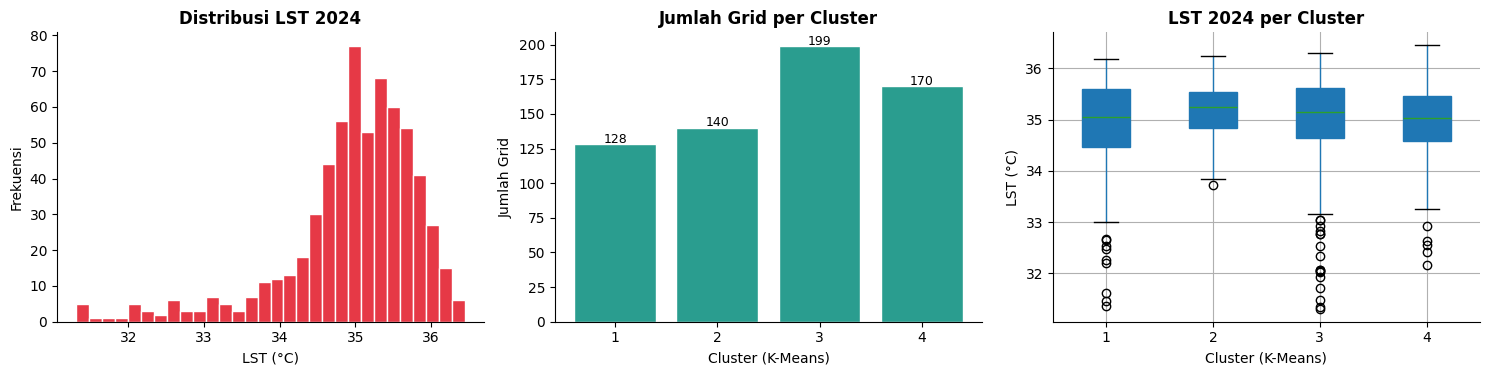


Statistik Deskriptif (target + lag LST):


,lst_2024,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021
count,637.000,637.000,637.000,637.000,637.000,637.000
mean,34.963,37.309,36.950,38.070,38.365,37.162
std,0.883,1.420,1.205,1.196,1.154,1.084
min,31.311,32.359,32.108,32.781,33.390,32.657
25%,34.652,36.683,36.596,37.750,38.041,36.767
50%,35.089,37.481,37.234,38.316,38.605,37.311
75%,35.547,38.131,37.714,38.794,39.118,37.871
max,36.444,40.508,38.829,40.121,40.257,39.235


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
axes[0].hist(df[f'lst_{TARGET_YEAR}'], bins=30, color='#E63946', edgecolor='white')
axes[0].set_title(f'Distribusi LST {TARGET_YEAR}', fontweight='bold')
axes[0].set_xlabel('LST (°C)')
axes[0].set_ylabel('Frekuensi')

# Distribusi cluster
vc = df[CLUSTER_COL].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='#2A9D8F', edgecolor='white')
axes[1].set_title('Jumlah Grid per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster (K-Means)')
axes[1].set_ylabel('Jumlah Grid')
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

# Boxplot LST 2024 per cluster
df.boxplot(column=f'lst_{TARGET_YEAR}', by=CLUSTER_COL, ax=axes[2],
           patch_artist=True)
axes[2].set_title(f'LST {TARGET_YEAR} per Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster (K-Means)')
axes[2].set_ylabel('LST (°C)')
plt.suptitle('')

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistik Deskriptif (target + lag LST):')
display(df[[f'lst_{TARGET_YEAR}'] + lst_cols].describe().round(3))

## 🔧 Sel 6 — Definisi Fitur & Fungsi Helper

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  DEFINISI FITUR UNTUK 4 KONFIGURASI MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TARGET_COL = f'lst_{TARGET_YEAR}'

MODEL_CONFIGS = {
    'M1_LagLST': {
        'label'           : 'M1: Lag LST saja',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}',
        'features'        : lst_cols,
        'split_by_cluster': False,
    },
    'M2_LagLST_byCluster': {
        'label'           : 'M2: Lag LST (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}, model dilatih per cluster',
        'features'        : lst_cols,
        'split_by_cluster': True,
    },
    'M3_LagAll': {
        'label'           : 'M3: Lag LST + NDVI + NDBI',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': False,
    },
    'M4_LagAll_byCluster': {
        'label'           : 'M4: Lag LST + NDVI + NDBI (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}, per cluster',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': True,
    },
}

print('✅ Konfigurasi model:')
print(f'   lst_cols  ({len(lst_cols)}): {lst_cols}')
print(f'   ndvi_cols ({len(ndvi_cols)}): {ndvi_cols}')
print(f'   ndbi_cols ({len(ndbi_cols)}): {ndbi_cols}')
print()
for key, cfg in MODEL_CONFIGS.items():
    split_info = f'split per {CLUSTER_COL}' if cfg['split_by_cluster'] else 'semua data'
    print(f'   {cfg["label"]}')
    print(f'      Fitur ({len(cfg["features"])}): {cfg["desc"]}')
    print(f'      Data : {split_info}')

✅ Konfigurasi model:
   lst_cols  (5): ['lst_2009', 'lst_2012', 'lst_2015', 'lst_2018', 'lst_2021']
   ndvi_cols (6): ['ndvi2009', 'ndvi2012', 'ndvi2015', 'ndvi2018', 'ndvi2021', 'ndvi2024']
   ndbi_cols (6): ['ndbi2009', 'ndbi2012', 'ndbi2015', 'ndbi2018', 'ndbi2021', 'ndbi2024']

   M1: Lag LST saja
      Fitur (5): lst 2009–2021
      Data : semua data
   M2: Lag LST (per Cluster)
      Fitur (5): lst 2009–2021, model dilatih per cluster
      Data : split per kmeans_cluster
   M3: Lag LST + NDVI + NDBI
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024
      Data : semua data
   M4: Lag LST + NDVI + NDBI (per Cluster)
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024, per cluster
      Data : split per kmeans_cluster


In [8]:
def build_estimator(algorithm):
    if algorithm == 'RF':
        return RandomForestRegressor(**RF_PARAMS)
    return Pipeline([('scaler', StandardScaler()), ('svr', SVR(**SVR_PARAMS))])


def calculate_metrics(actual, predicted, n_features, prefix=''):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    score = r2_score(actual, predicted)
    n = len(actual)
    nonzero = actual != 0
    values = dict(R2=score,
        Adj_R2=1-(1-score)*(n-1)/(n-n_features-1) if n>n_features+1 else np.nan,
        RMSE=np.sqrt(mean_squared_error(actual,predicted)),
        MAE=mean_absolute_error(actual,predicted),
        MAPE=np.mean(np.abs((actual[nonzero]-predicted[nonzero])/actual[nonzero]))*100 if nonzero.any() else np.nan)
    return {prefix+name:float(value) for name,value in values.items()}


def fit_models(features, algorithm, train_indices, per_cluster):
    fitted = {}
    labels = sorted(df.loc[train_indices,CLUSTER_COL].unique()) if per_cluster else ['global']
    for label in labels:
        # Urutan latih per klaster mengikuti notebook awal (urutan baris df).
        members = np.sort(train_indices[df.loc[train_indices,CLUSTER_COL].to_numpy()==label]) if per_cluster else train_indices
        estimator = build_estimator(algorithm)
        estimator.fit(df.loc[members,features].values,df.loc[members,TARGET_COL].values)
        fitted[label] = estimator
    return fitted


def predict_models(fitted, features, indices, per_cluster):
    predicted = np.full(len(indices),np.nan)
    labels = df.loc[indices,CLUSTER_COL].to_numpy()
    for label, estimator in fitted.items():
        mask = labels==label if per_cluster else np.ones(len(indices),dtype=bool)
        if mask.any():
            predicted[mask] = estimator.predict(df.loc[indices[mask],features].values)
    if not np.isfinite(predicted).all():
        raise ValueError('Ada grid tanpa prediksi/model klaster.')
    return predicted


def evaluate_model(config, algorithm, train_indices, test_indices, folds):
    features, per_cluster = config['features'],config['split_by_cluster']
    cv_scores = []
    for a,b in folds:
        tr,va = train_indices[a],train_indices[b]
        fitted_fold = fit_models(features,algorithm,tr,per_cluster)
        predicted_fold = predict_models(fitted_fold,features,va,per_cluster)
        cv_scores.append(r2_score(df.loc[va,TARGET_COL],predicted_fold))
    fitted = fit_models(features,algorithm,train_indices,per_cluster)
    train_prediction = predict_models(fitted,features,train_indices,per_cluster)
    test_prediction = predict_models(fitted,features,test_indices,per_cluster)
    scores = calculate_metrics(df.loc[train_indices,TARGET_COL],train_prediction,len(features),'Train_')
    scores.update(calculate_metrics(df.loc[test_indices,TARGET_COL],test_prediction,len(features),'Test_'))
    scores.update(CV_R2_Mean=float(np.mean(cv_scores)),CV_R2_Std=float(np.std(cv_scores)))
    result = dict(**scores,features=features,models=fitted,
                  y_test=df.loc[test_indices,TARGET_COL].values,y_pred_test=test_prediction,
                  y_train=df.loc[train_indices,TARGET_COL].values,y_pred_train=train_prediction,
                  X_test=df.loc[test_indices,features].values,X_train=df.loc[train_indices,features].values)
    if per_cluster:
        result['idx_test_union'] = test_indices.copy()
        result['cluster_models'] = {cl:{algorithm:estimator} for cl,estimator in fitted.items()}
        result['cluster_X_train'] = {cl:df.loc[train_indices[df.loc[train_indices,CLUSTER_COL].to_numpy()==cl],features].values for cl in fitted}
        # model_obj tidak dipakai sebagai proxy model global.
    else:
        result['model_obj'] = fitted['global']
    return result


## 🚀 Sel 7 — Training Semua Model (RF + SVR × 4 Konfigurasi)

In [9]:
idx_train_global,idx_test_global = train_test_split(
    np.arange(len(df)),test_size=TEST_SIZE,random_state=SEED)
folds = list(KFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED).split(idx_train_global))
clusters = sorted(df[CLUSTER_COL].unique())
all_results,summary_rows = {},[]
for config_key,config in MODEL_CONFIGS.items():
    for algorithm in ['RF','SVR']:
        print('Melatih:',config_key,algorithm,flush=True)
        result = evaluate_model(config,algorithm,idx_train_global,idx_test_global,folds)
        all_results[(config_key,algorithm)] = result
        summary_rows.append(dict(Config=config['label'],Algorithm=algorithm,
            N_Features=len(config['features']),Split='Per Cluster' if config['split_by_cluster'] else 'Semua Grid',
            **{name:result[name] for name in result if name.startswith(('Train_','Test_','CV_'))}))
df_summary = pd.DataFrame(summary_rows)
print('Delapan model selesai. CV memakai grid latih saja.')


Melatih: M1_LagLST RF
Melatih: M1_LagLST SVR
Melatih: M2_LagLST_byCluster RF
Melatih: M2_LagLST_byCluster SVR
Melatih: M3_LagAll RF
Melatih: M3_LagAll SVR
Melatih: M4_LagAll_byCluster RF
Melatih: M4_LagAll_byCluster SVR
Delapan model selesai. CV memakai grid latih saja.


MODEL TERBAIK DATA LAMA: M4 RF | R2 uji: 0.9398104930741664 | RMSE uji: 0.20778894200211265


,grid_id,cluster,aktual,prediksi,selisih,split,model,algoritma
0,93175000687,4,35.200179,35.184549,-0.015630,train,M4,RF
1,93185000687,4,35.004790,35.057631,0.052841,train,M4,RF
2,93195000687,4,35.015022,35.149593,0.134570,test,M4,RF
3,93205000687,4,35.079468,35.099070,0.019603,train,M4,RF
4,93215000687,1,34.830626,34.904151,0.073526,train,M4,RF


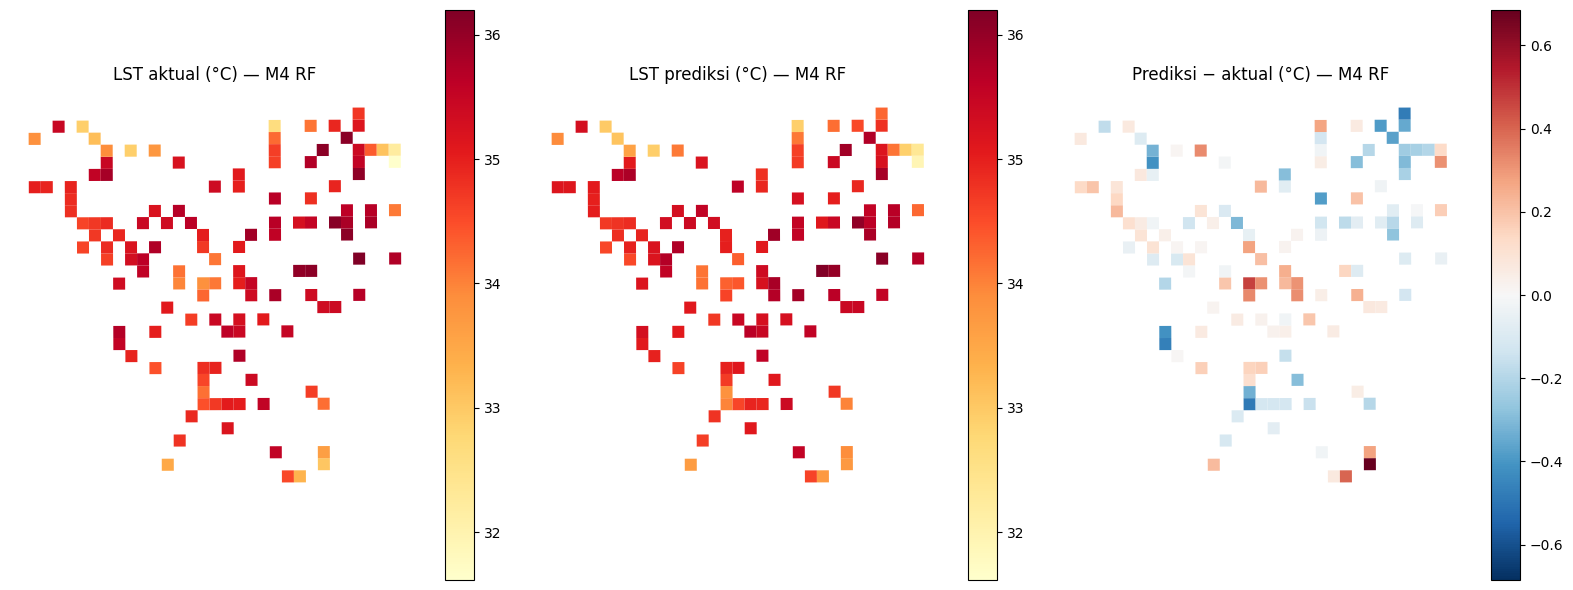

In [10]:
"""Sel ekspor notebook awal: dieksekusi setelah seluruh delapan model selesai.

Kode ini juga disalin ke notebook agar notebook tetap mandiri di Colab.
"""
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path
import joblib

# Gunakan M4?RF sebagai model utama penelitian; evaluasi tetap apa adanya.
ranking = []
test_export = df.iloc[idx_test_global][['grid_id', TARGET_COL, CLUSTER_COL]].copy()
test_export = test_export.rename(columns={CLUSTER_COL: 'Cluster'}).set_index('grid_id')
for (key, algorithm), result in all_results.items():
    config = MODEL_CONFIGS[key]
    test_idx = np.asarray(result['idx_test_union'] if config['split_by_cluster'] else idx_test_global)
    ids = df.iloc[test_idx]['grid_id'].to_numpy()
    if set(ids) != set(test_export.index) or len(ids) != len(set(ids)):
        raise ValueError('Keanggotaan grid uji antar model tidak identik.')
    aligned = pd.Series(result['y_pred_test'], index=ids)
    column = f'pred_{key}_{algorithm}'
    test_export[column] = aligned.reindex(test_export.index)
    score = r2_score(test_export[TARGET_COL], test_export[column])
    rmse = np.sqrt(mean_squared_error(test_export[TARGET_COL], test_export[column]))
    ranking.append(dict(key=key, algorithm=algorithm, r2=float(score), rmse=float(rmse)))
    if abs(score-result['Test_R2']) > 0.000051:
        raise ValueError('Metrik prediksi tersimpan tidak sesuai hasil model.')
best = next(row for row in ranking if row['key'] == 'M4_LagAll_byCluster' and row['algorithm'] == 'RF')
best_key, best_algorithm = best['key'], best['algorithm']
best_config = MODEL_CONFIGS[best_key]
best_result = all_results[(best_key, best_algorithm)]
all_prediction = np.full(len(df), np.nan)
if best_config['split_by_cluster']:
    fitted_models = {}
    for cluster in sorted(df[CLUSTER_COL].unique()):
        members = df.index[df[CLUSTER_COL].eq(cluster)].to_numpy()
        estimator = best_result['cluster_models'][cluster][best_algorithm]
        all_prediction[members] = estimator.predict(df.loc[members, best_config['features']].values)
        fitted_models[str(int(cluster))] = estimator
else:
    fitted_models = {'global': best_result['model_obj']}
    all_prediction = best_result['model_obj'].predict(df[best_config['features']].values)
if not np.isfinite(all_prediction).all():
    raise ValueError('Prediksi model terbaik tidak lengkap.')
best_predictions = df[['grid_id', CLUSTER_COL, TARGET_COL]].rename(
    columns={CLUSTER_COL:'cluster', TARGET_COL:'aktual'}).copy()
best_predictions['prediksi'] = all_prediction
best_predictions['selisih'] = best_predictions['prediksi']-best_predictions['aktual']
best_predictions['split'] = np.where(df.index.isin(idx_test_global), 'test', 'train')
best_predictions['model'] = best_key.split('_')[0]
best_predictions['algoritma'] = best_algorithm
test_best = best_predictions[best_predictions['split'].eq('test')]
np.testing.assert_allclose(r2_score(test_best['aktual'],test_best['prediksi']),best['r2'],atol=1e-10)
test_export.reset_index().to_csv(OUTPUT_DIR+'all_predictions_test_set.csv',index=False)
best_predictions.to_csv(OUTPUT_DIR+'best_model_predictions.csv',index=False)
df_summary.to_csv(OUTPUT_DIR+'summary_evaluation.csv',index=False)
joblib.dump(dict(models=fitted_models,features=best_config['features'],
                 split_by_cluster=best_config['split_by_cluster']),OUTPUT_DIR+'best_model.joblib')

manifest = dict(created_utc=datetime.now(timezone.utc).isoformat(),
    source='legacy_pre_harmonization', selection='research_model_m4_rf',
    selection_label='M4-RF ditetapkan sebagai model utama penelitian',
    best_model=best_key.split('_')[0],best_config=best_key,best_algorithm=best_algorithm,
    best_label=best_config['label'],n_features=len(best_config['features']),
    test_r2=best['r2'],test_rmse=best['rmse'],
    test_mae=float(mean_absolute_error(test_best['aktual'],test_best['prediksi'])),
    n_train=len(idx_train_global),n_test=len(idx_test_global),n_complete=len(df),
    ndvi_ndbi_years=ndvi_ndbi_years,seed=SEED,
    residual_definition='prediction_minus_actual',
    inputs={str(Path(p).resolve()):hashlib.sha256(Path(p).read_bytes()).hexdigest()
            for p in [PATH_NDVI_NDBI,PATH_CLUSTER,PATH_LST_CSV]})
Path(OUTPUT_DIR+'best_model.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
print('MODEL TERBAIK DATA LAMA:',manifest['best_model'],best_algorithm,
      '| R2 uji:',best['r2'],'| RMSE uji:',best['rmse'])
display(best_predictions.head())

# Peta holdout: tidak menggabungkan galat latih ke dalam evaluasi data uji.
spatial = gdf_ndvi[['grid_id','geometry']].merge(best_predictions,on='grid_id',validate='one_to_one')
spatial = gpd.GeoDataFrame(spatial,geometry='geometry',crs=gdf_ndvi.crs)
spatial.to_file(OUTPUT_DIR+'best_model_predictions.geojson',driver='GeoJSON')
test_map = spatial[spatial['split'].eq('test')]
fig, axes = plt.subplots(1,3,figsize=(16,6))
lower = min(test_map['aktual'].min(),test_map['prediksi'].min())
upper = max(test_map['aktual'].max(),test_map['prediksi'].max())
limit = max(float(test_map['selisih'].abs().max()),.01)
for ax,column,title in zip(axes,['aktual','prediksi','selisih'],
                           ['LST aktual','LST prediksi','Prediksi − aktual']):
    kwargs = dict(cmap='RdBu_r',vmin=-limit,vmax=limit) if column=='selisih' else dict(cmap='YlOrRd',vmin=lower,vmax=upper)
    test_map.plot(column=column,ax=ax,legend=True,**kwargs)
    ax.set_title(f'{title} (°C) — {manifest["best_model"]} {best_algorithm}')
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUTPUT_DIR+'peta_model_terbaik_holdout.png',dpi=160)
plt.show()
plt.close(fig)


## 📋 Sel 8 — Tabel Hasil Evaluasi

In [11]:
display(df_summary.round(4))
print('Model terbaik:', manifest['best_model'],manifest['best_algorithm'])
print('Kriteria:',manifest['selection_label'])
print('Grid latih:',manifest['n_train'],'| Grid uji:',manifest['n_test'])
print('Output:',OUTPUT_DIR)


,Config,Algorithm,N_Features,Split,Train_R2,Train_Adj_R2,Train_RMSE,Train_MAE,Train_MAPE,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE,CV_R2_Mean,CV_R2_Std
0,M1: Lag LST saja,RF,5,Semua Grid,0.9913,0.9912,0.0833,0.0656,0.1881,0.9361,0.9335,0.2140,0.1656,0.4765,0.9329,0.0132
1,M1: Lag LST saja,SVR,5,Semua Grid,0.9607,0.9603,0.1768,0.1378,0.3938,0.9473,0.9452,0.1944,0.1537,0.4408,0.9394,0.0107
2,M2: Lag LST (per Cluster),RF,5,Per Cluster,0.9912,0.9912,0.0834,0.0632,0.1818,0.9330,0.9303,0.2192,0.1662,0.4779,0.9360,0.0074
3,M2: Lag LST (per Cluster),SVR,5,Per Cluster,0.9774,0.9772,0.1340,0.1068,0.3052,0.9466,0.9444,0.1957,0.1482,0.4249,0.9457,0.0054
4,M3: Lag LST + NDVI + NDBI,RF,17,Semua Grid,0.9923,0.9921,0.0780,0.0600,0.1722,0.9362,0.9263,0.2139,0.1666,0.4789,0.9420,0.0109
5,M3: Lag LST + NDVI + NDBI,SVR,17,Semua Grid,0.9855,0.9850,0.1075,0.0907,0.2592,0.9520,0.9446,0.1855,0.1444,0.4148,0.9182,0.0209
6,M4: Lag LST + NDVI + NDBI (per Cluster),RF,17,Per Cluster,0.9906,0.9902,0.0865,0.0621,0.1787,0.9398,0.9305,0.2078,0.1620,0.4659,0.9268,0.0063
7,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,17,Per Cluster,0.9901,0.9898,0.0886,0.0806,0.2306,0.9462,0.9379,0.1964,0.1483,0.4274,0.8736,0.0449


Model terbaik: M4 RF
Kriteria: M4-RF ditetapkan sebagai model utama penelitian
Grid latih: 509 | Grid uji: 128
Output: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\


## 📊 Sel 9 — Plot Perbandingan Metrik

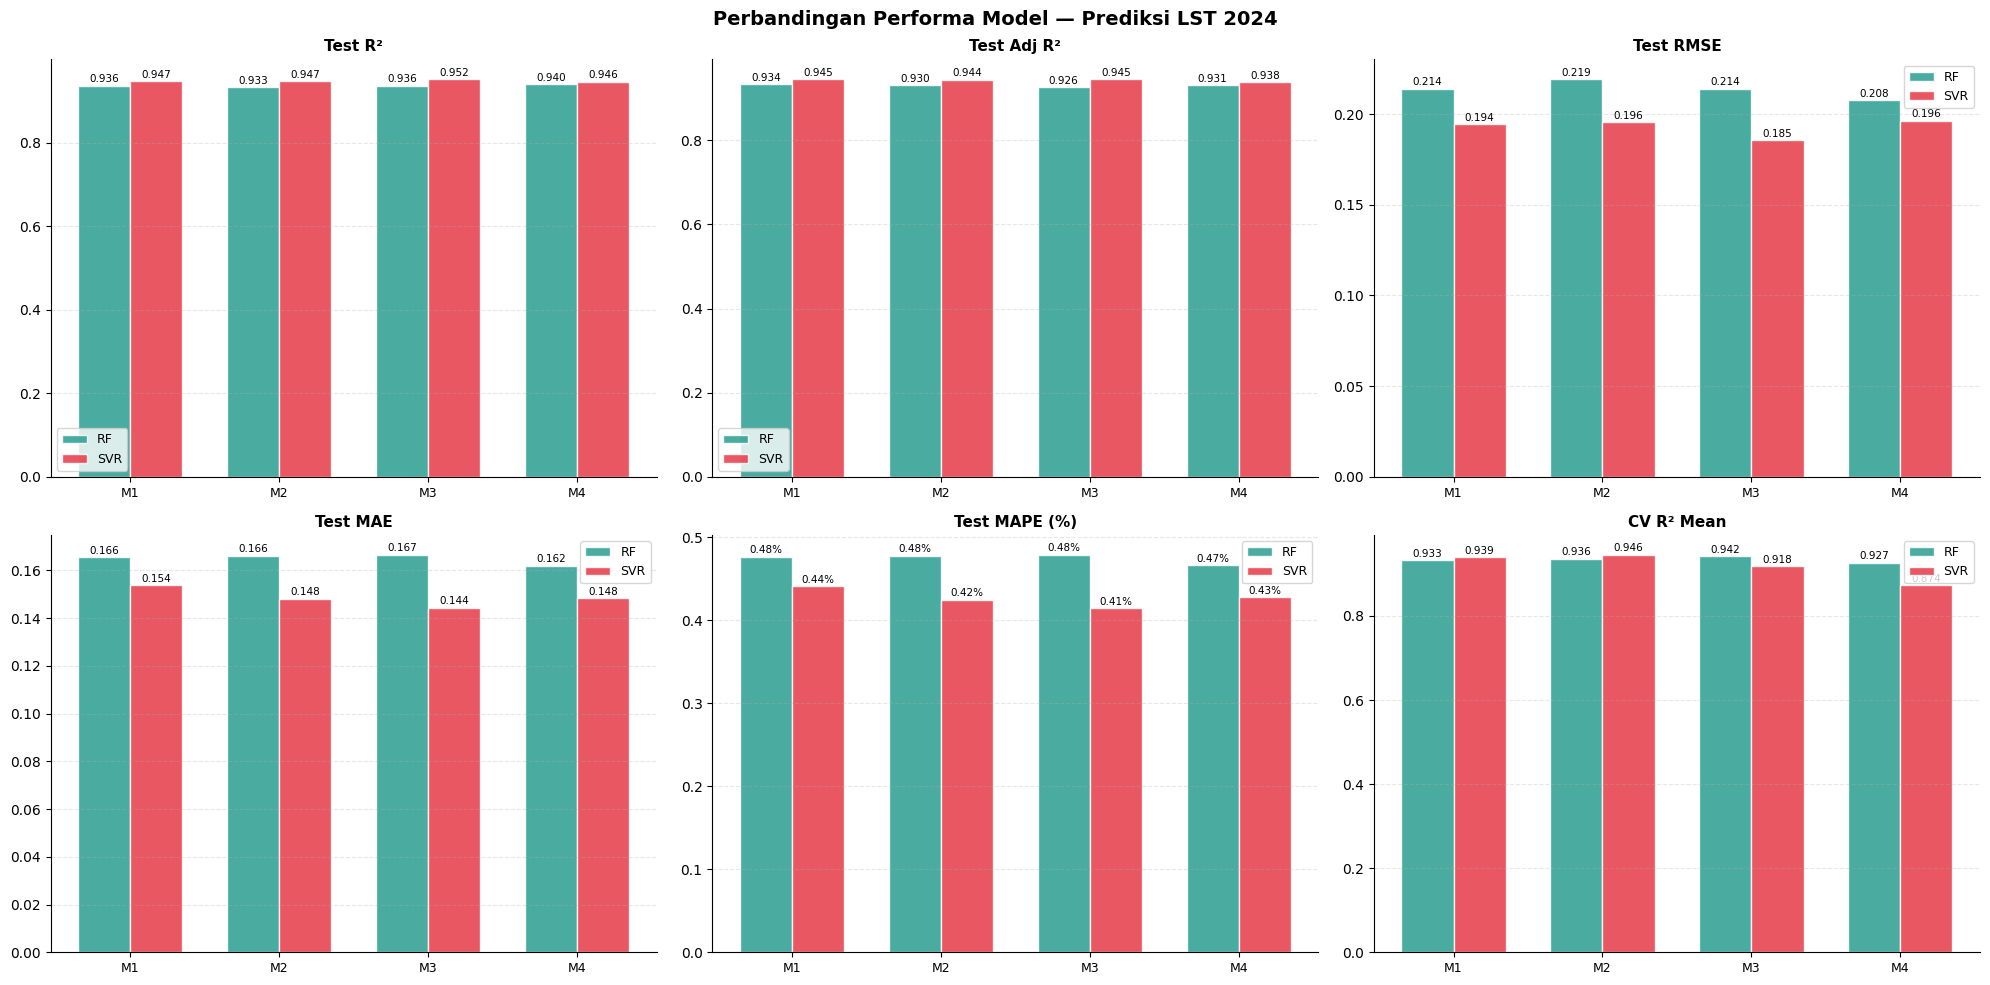

💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\plot_metrics_comparison.png


In [12]:
metrics     = ['Test_R2', 'Test_Adj_R2', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'CV_R2_Mean']
m_titles    = ['Test R²', 'Test Adj R²', 'Test RMSE', 'Test MAE', 'Test MAPE (%)', 'CV R² Mean']
algos       = ['RF', 'SVR']
configs     = [cfg['label'] for cfg in MODEL_CONFIGS.values()]
x           = np.arange(len(configs))
width       = 0.35
algo_colors = ['#2A9D8F', '#E63946']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(f'Perbandingan Performa Model — Prediksi LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes.flatten(), metrics, m_titles):
    for i, algo in enumerate(algos):
        vals = df_summary[df_summary['Algorithm'] == algo][metric].values
        bars = ax.bar(x + i * width - width/2, vals, width,
                      label=algo, color=algo_colors[i], alpha=0.85,
                      edgecolor='white')
        fmt = '%.2f%%' if metric == 'Test_MAPE' else '%.3f'
        ax.bar_label(bars, fmt=fmt, fontsize=7.5, padding=1)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.split(':')[0] for c in configs], fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_metrics_comparison.png')

## 🎯 Sel 10 — Plot Prediksi vs Aktual (Scatter)

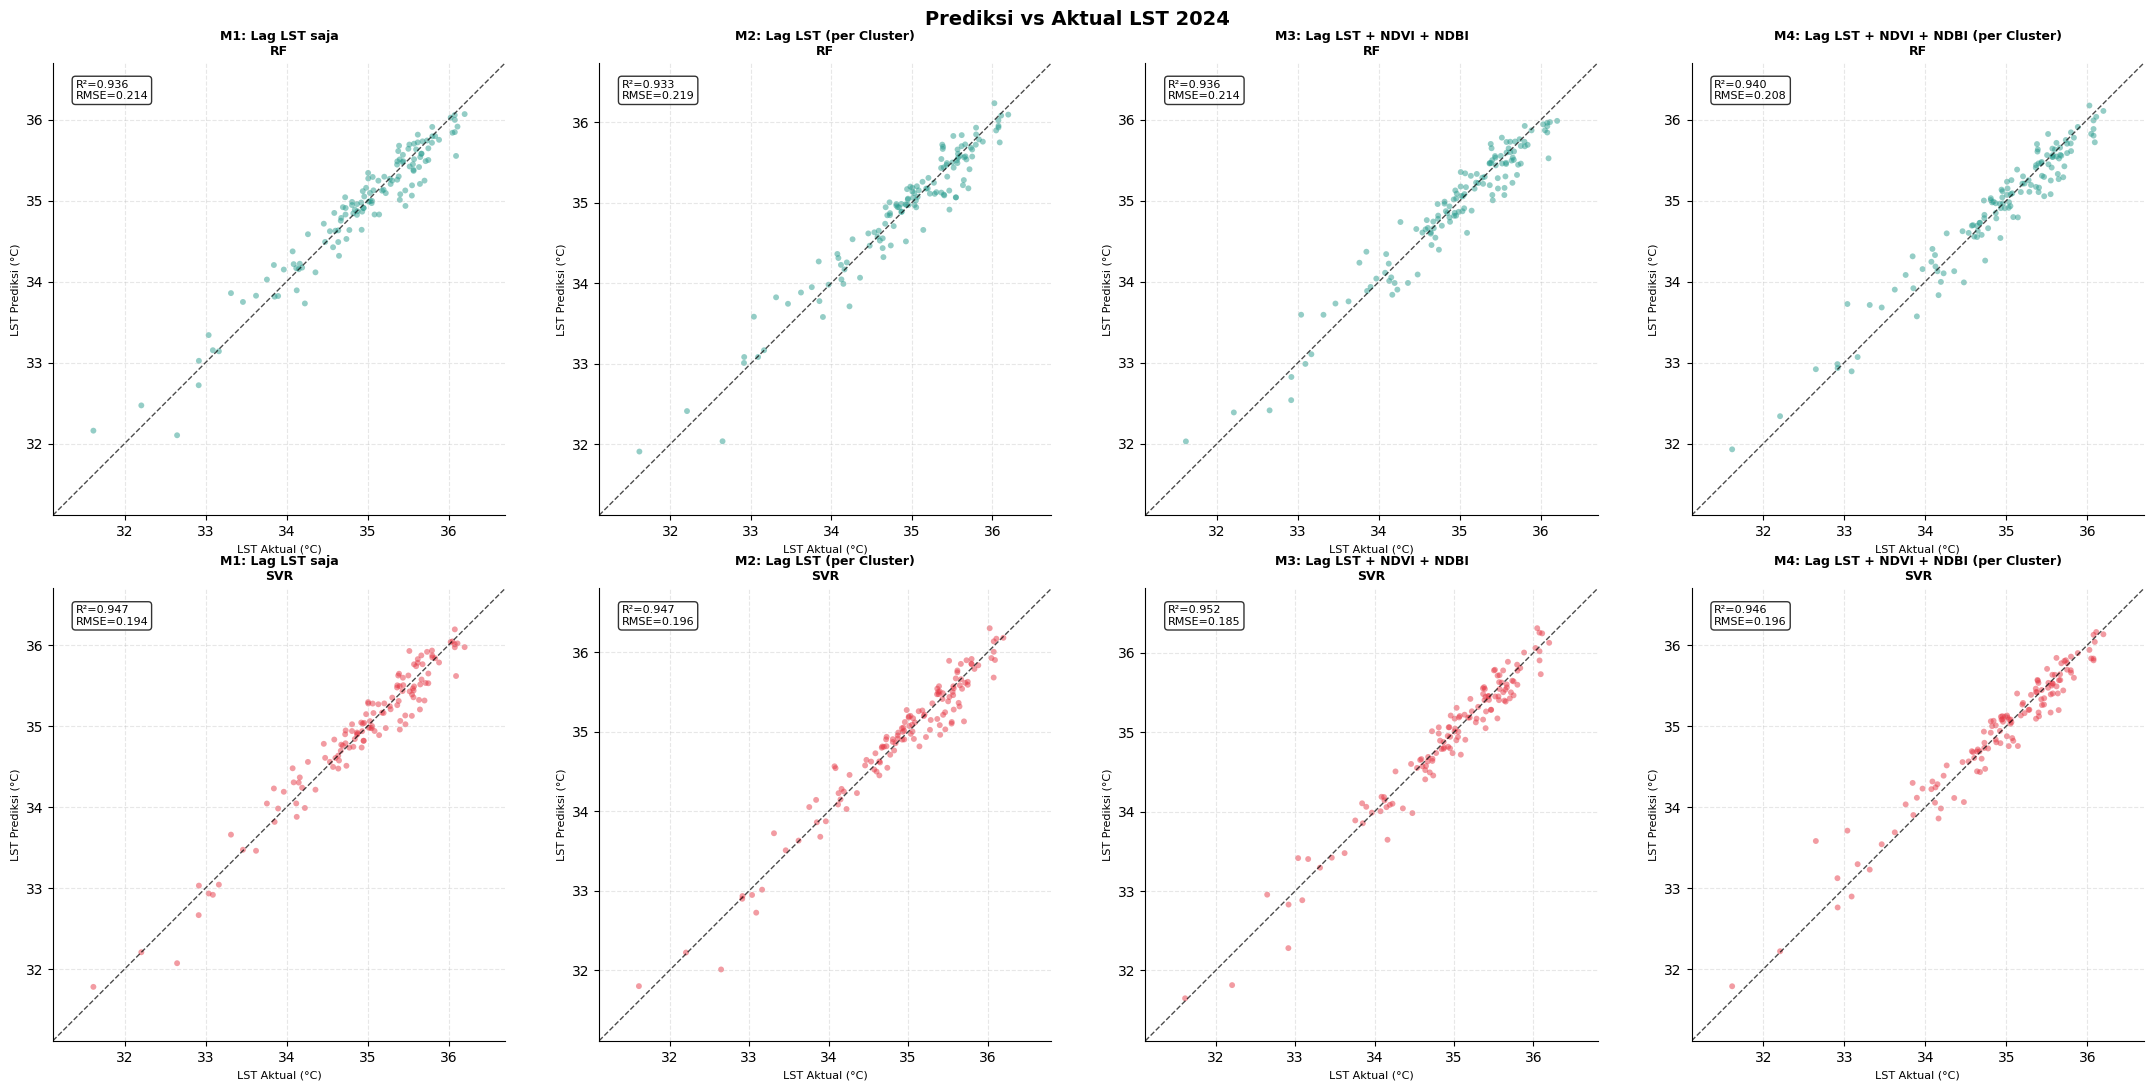

💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\plot_scatter_pred_vs_actual.png


In [13]:
cfg_keys = list(MODEL_CONFIGS.keys())
n_cfg    = len(cfg_keys)
n_algo   = 2  # RF, SVR

fig, axes = plt.subplots(n_algo, n_cfg, figsize=(5.5 * n_cfg, 5.5 * n_algo))
fig.suptitle(f'Prediksi vs Aktual LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

palette_scatter = ['#2A9D8F', '#E63946']

for row_i, algo in enumerate(['RF', 'SVR']):
    for col_i, cfg_key in enumerate(cfg_keys):
        ax   = axes[row_i][col_i]
        res  = all_results[(cfg_key, algo)]
        y_t  = res['y_test']
        y_p  = res['y_pred_test']
        r2   = res['Test_R2']
        rmse = res['Test_RMSE']

        ax.scatter(y_t, y_p, alpha=0.5, s=18,
                   color=palette_scatter[row_i], edgecolors='none')

        # Garis perfect prediction
        lims = [min(y_t.min(), y_p.min()) - 0.5,
                max(y_t.max(), y_p.max()) + 0.5]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7)

        ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n{algo}',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('LST Aktual (°C)', fontsize=8)
        ax.set_ylabel('LST Prediksi (°C)', fontsize=8)
        ax.text(0.05, 0.92, f'R²={r2:.3f}\nRMSE={rmse:.3f}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3, linestyle='--')
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_scatter_pred_vs_actual.png')

## 🌲 Sel 11 — Feature Importance (Random Forest)

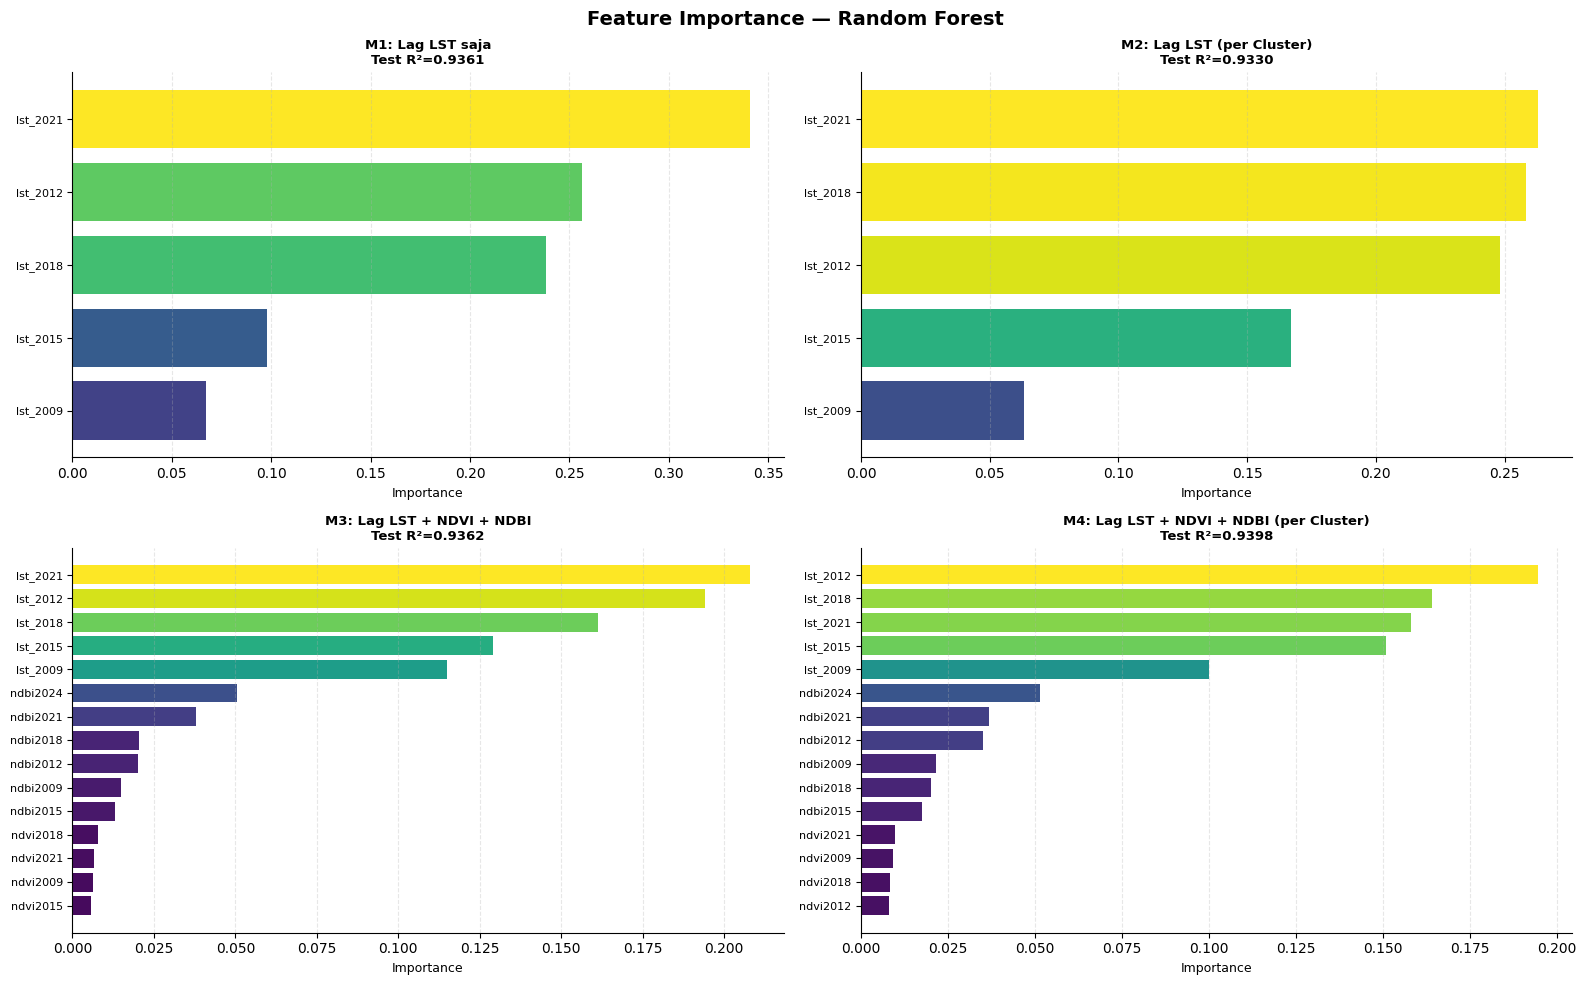

💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\plot_feature_importance_rf.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')

colors_fi = plt.cm.viridis

for ax, cfg_key in zip(axes.flatten(), cfg_keys):
    res      = all_results[(cfg_key, 'RF')]
    feats    = res['features']
    if MODEL_CONFIGS[cfg_key]['split_by_cluster']:
        weights = [len(res['cluster_X_train'][cl]) for cl in clusters]
        imps = np.average([res['cluster_models'][cl]['RF'].feature_importances_ for cl in clusters], axis=0, weights=weights)
    else:
        imps = res['models']['global'].feature_importances_

    # Sort descending
    sorted_idx = np.argsort(imps)[::-1]
    top_n      = min(15, len(feats))
    top_idx    = sorted_idx[:top_n]

    top_feats = [feats[i] for i in top_idx]
    top_imps  = imps[top_idx]

    bar_colors = [colors_fi(v / top_imps.max()) for v in top_imps]
    bars = ax.barh(range(top_n), top_imps[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n'
                 f'Test R²={res["Test_R2"]:.4f}',
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_feature_importance_rf.png')


## Sel 12 — Vector SHAP per variabel dan klaster

Adaptasi kode lampiran untuk hasil RF M1–M4 pada notebook ini. Jalankan sel sebelumnya terlebih dahulu. M4–RF tetap menjadi model utama; setiap grid dijelaskan memakai estimator klasternya sendiri.

Seluruh tahun suatu variabel menjadi satu kelompok. Baseline memakai **rata-rata fitur data latih** model terkait, bukan data uji. Ringkasan keseluruhan menggabungkan kontribusi semua grid uji (berbobot jumlah grid), dengan baseline berbeda untuk setiap model klaster. SHAP standar menggunakan baseline yang sama untuk perbandingan.

Batang menampilkan rata-rata kontribusi absolut (°C), garis Q25–Q75, dan tanda median. IQR merupakan sebaran kontribusi, bukan interval kepercayaan. Nilai absolut tidak menunjukkan arah pengaruh atau hubungan sebab-akibat. NDVI/NDBI 2024 adalah fitur tahun target, bukan lag sebelum 2024.

Referensi Choi et al. (2025) mengikuti lampiran pengguna. Pemeriksaan numerik di sini menguji rekonstruksi prediksi, bukan membuktikan kesesuaian seluruh implementasi dengan artikel. Hasil baru disimpan dalam subfolder `vector_shap` dari `OUTPUT_DIR`.


📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]
   Persamaan (4)-(8): Kernel SHAP di level J variabel


c:\Users\Solideo G. Bangun\anaconda3\envs\env_baru\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


M1_LagLST, global: galat rekonstruksi SHAP standar = 0.00024253 °C

✅ Verifikasi Vector Local Accuracy — M1: Lag LST saja
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi


,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,All,LST,0.594361,0.526645,0.046549,0.220625,0.815137,0.520568,100.0,128


💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap\true_vector_shap_overall_M1_LagLST.png


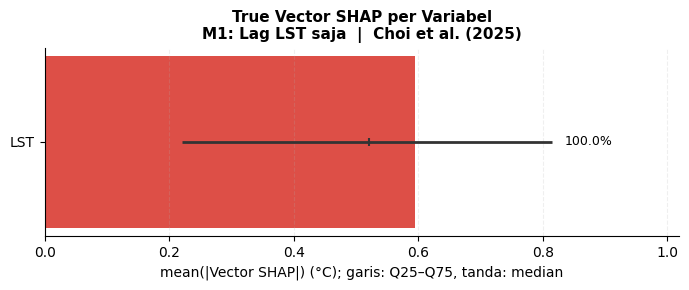

M2_LagLST_byCluster, 1: galat rekonstruksi SHAP standar = 0.00000064 °C
M2_LagLST_byCluster, 2: galat rekonstruksi SHAP standar = 0.00024240 °C
M2_LagLST_byCluster, 3: galat rekonstruksi SHAP standar = 0.00000083 °C
M2_LagLST_byCluster, 4: galat rekonstruksi SHAP standar = 0.00000102 °C

✅ Verifikasi Vector Local Accuracy — M2: Lag LST (per Cluster)
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi


,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,All,LST,0.586288,0.557838,0.049306,0.135087,0.838081,0.457373,100.0,128


💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap\true_vector_shap_overall_M2_LagLST_byCluster.png


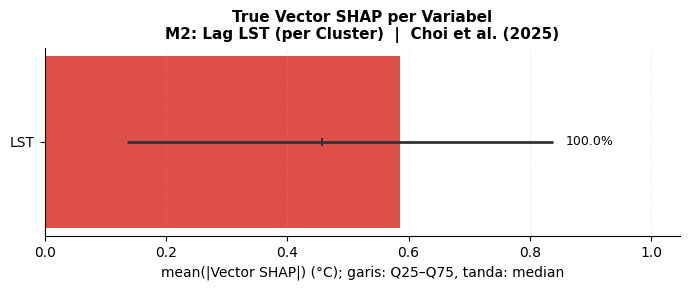

,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,1,LST,0.943724,0.756122,0.140408,0.528079,0.992452,0.785405,100.0,29
1,2,LST,0.415899,0.345205,0.066435,0.129144,0.605640,0.339195,100.0,27
2,3,LST,0.555713,0.452760,0.073447,0.225050,0.819756,0.443532,100.0,38
3,4,LST,0.450897,0.456867,0.078352,0.088841,0.657743,0.347352,100.0,34


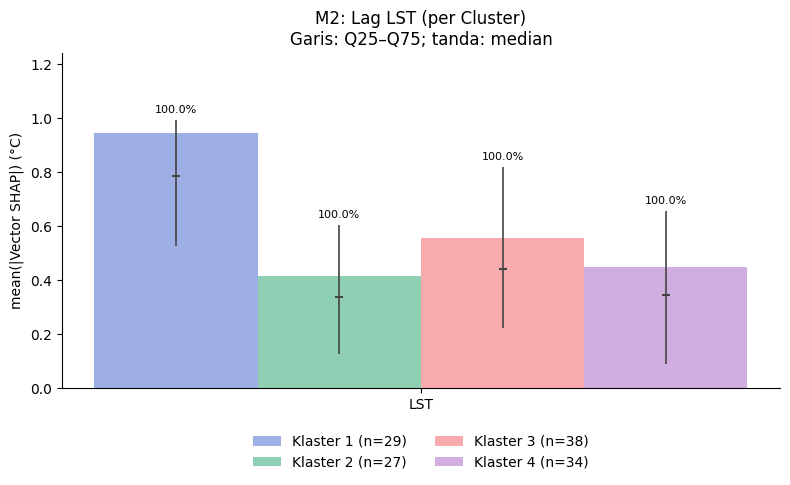

M3_LagAll, global: galat rekonstruksi SHAP standar = 0.00000090 °C

✅ Verifikasi Vector Local Accuracy — M3: Lag LST + NDVI + NDBI
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi


,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,All,LST,0.497601,0.485661,0.042927,0.163852,0.671079,0.395903,77.86,128
1,All,NDBI,0.115071,0.107084,0.009465,0.038065,0.140045,0.081450,18.00,128
2,All,NDVI,0.026464,0.022203,0.001962,0.008266,0.039503,0.019410,4.14,128


💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap\true_vector_shap_overall_M3_LagAll.png


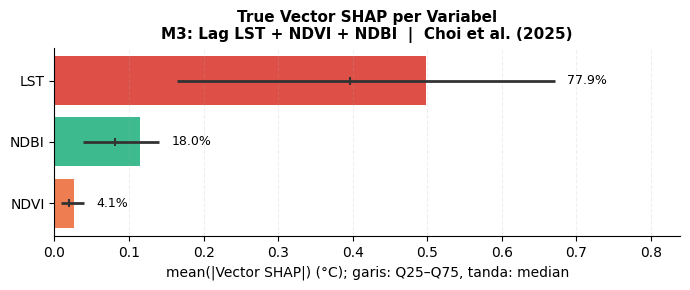

M4_LagAll_byCluster, 1: galat rekonstruksi SHAP standar = 0.00000058 °C
M4_LagAll_byCluster, 2: galat rekonstruksi SHAP standar = 0.00000045 °C
M4_LagAll_byCluster, 3: galat rekonstruksi SHAP standar = 0.00000063 °C
M4_LagAll_byCluster, 4: galat rekonstruksi SHAP standar = 0.00000114 °C

✅ Verifikasi Vector Local Accuracy — M4: Lag LST + NDVI + NDBI (per Cluster)
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi


,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,All,LST,0.481423,0.434138,0.038373,0.129122,0.697455,0.369380,77.65,128
1,All,NDBI,0.110377,0.105200,0.009298,0.044710,0.139650,0.077175,17.80,128
2,All,NDVI,0.028196,0.035985,0.003181,0.007373,0.032939,0.018407,4.55,128


💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap\true_vector_shap_overall_M4_LagAll_byCluster.png


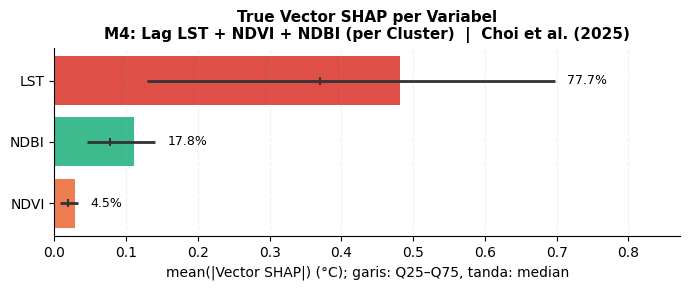

,cluster,variable,vector_shap_mean,vector_shap_std,vector_shap_sem,vector_shap_q25,vector_shap_q75,vector_shap_median,vector_shap_pct,n_samples
0,1,LST,0.742076,0.537883,0.099882,0.370769,0.837968,0.704037,77.87,29
1,1,NDBI,0.158627,0.141930,0.026356,0.057037,0.180773,0.122474,16.64,29
2,1,NDVI,0.052300,0.058777,0.010915,0.013130,0.056083,0.029253,5.49,29
3,2,LST,0.343290,0.249992,0.048111,0.117962,0.494198,0.318470,77.44,27
4,2,NDBI,0.076212,0.065519,0.012609,0.031785,0.091934,0.061173,17.19,27
5,2,NDVI,0.023771,0.014941,0.002875,0.009679,0.032560,0.025832,5.36,27
6,3,LST,0.479762,0.408790,0.066315,0.164339,0.668778,0.354074,82.98,38
7,3,NDBI,0.088817,0.066710,0.010822,0.045421,0.125487,0.061929,15.36,38
8,3,NDVI,0.009577,0.008225,0.001334,0.003531,0.013320,0.007556,1.66,38
9,4,LST,0.370652,0.375514,0.064400,0.049927,0.591689,0.243044,70.86,34


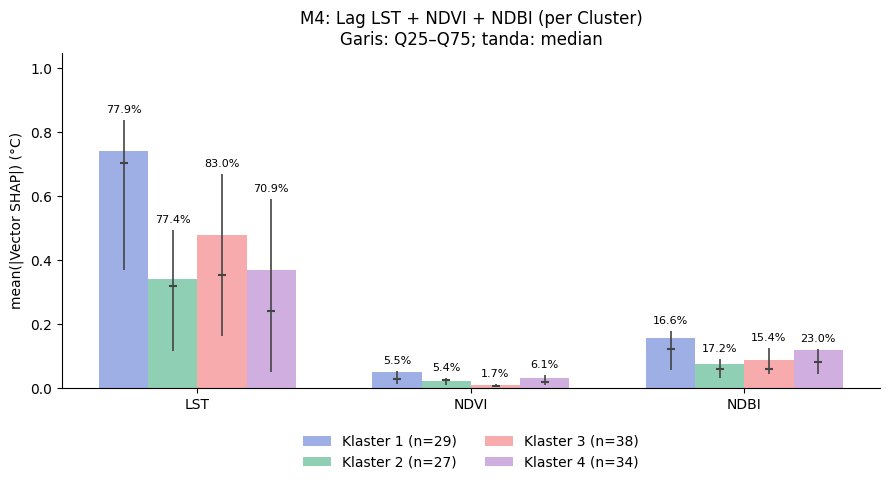


══════════════════════════════════════════════════════════════════════
  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — M4: Lag LST + NDVI + NDBI (per Cluster)
  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]
══════════════════════════════════════════════════════════════════════
variable  |Φⱼ| mean (True Vector)  |Φ⁰ⱼ| mean (Sum SHAP)  RMSD (Φⱼ vs Φ⁰ⱼ)  RMSD (% of std_prediction)
     LST                 0.481423               0.482502          0.006905                       0.878
    NDVI                 0.028196               0.027880          0.004236                       0.539
    NDBI                 0.110377               0.111854          0.006079                       0.773

  Rata-rata RMSD: 0.005740
  RMSD dihitung dari hasil model ini; bukan ambang kelulusan.
══════════════════════════════════════════════════════════════════════
💾 Disimpan: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap\phi_vs_phi0_scatter_M4_LagAll_byCluster.png


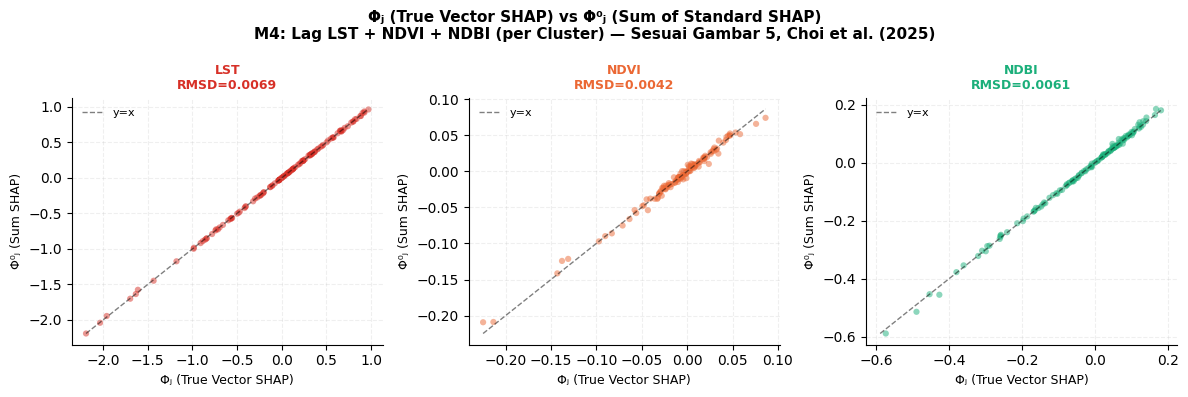

Selesai. Hasil Vector SHAP: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_legacy\vector_shap


In [15]:
import re
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.special import comb



# ─────────────────────────────────────────────────────────────────────────────
# UTILITAS
# ─────────────────────────────────────────────────────────────────────────────

def extract_year(feat_name: str):
    m = re.search(r'(19|20)\d{2}', feat_name)
    return int(m.group()) if m else None

def get_var_type(feat_name: str) -> str:
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'

COLOR_VAR = {'LST': '#d73027', 'NDVI': '#eb6834',
             'NDBI': '#1baf7a', 'LAINNYA': '#9e9e9e'}

CLUSTER_PALETTE = ['#9EAFE5', '#8FD0B5', '#F7ABAD', '#D0AFE0',
                   '#f57c00', '#0277bd']


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI INTI: TRUE VECTOR KERNEL SHAP
# Implementasi Persamaan (4)-(8) dari Choi et al. (2025)
# ═════════════════════════════════════════════════════════════════════════════

def _shap_kernel_weight(z: np.ndarray, J: int) -> float:
    """
    Kernel weight w(z) dari persamaan (6) jurnal Choi et al. (2025):
        w(z) = (J-1) / [C(J, |z|) * |z| * (J - |z|)]
    Di mana |z| adalah jumlah elemen 1 dalam z.
    Untuk |z|=0 atau |z|=J, w(z)=∞ (constraint penuh).
    """
    s = int(z.sum())
    if s == 0 or s == J:
        return np.inf
    return (J - 1) / (comb(J, s, exact=True) * s * (J - s))


def compute_true_vector_shap(
        model,
        X_test: np.ndarray,
        feature_names: list,
        var_groups: dict,
        background: np.ndarray = None) -> dict:
    """
    Implementasi Vector Kernel SHAP sesuai Choi et al. (2025),
    Persamaan (4)-(8).

    Ide utama (dari jurnal, hal. 636-637):
    - Perlakukan setiap variabel (LST, NDVI, NDBI) sebagai SATU pemain
    - z ∈ {0,1}^J: vektor biner sepanjang jumlah variabel J
    - zⱼ=1: gunakan nilai aktual Xⱼ
    - zⱼ=0: ganti seluruh lag Xⱼ dengan nilai mean (imputasi)
    - Jalankan Kernel SHAP di ruang J dimensi (bukan M dimensi)

    Parameter
    ---------
    model         : model terlatih dengan method .predict()
    X_test        : np.ndarray (n_samples, n_features)
    feature_names : list nama fitur
    var_groups    : dict {nama_variabel: [indeks_kolom]}
                    misal {'LST': [0,1,2,3,4], 'NDVI': [5,6,7,8,9,10]}
    background    : np.ndarray (n_bg, n_features), default=mean X_test

    Returns
    -------
    dict: {
        'phi'     : np.ndarray (n_samples, J) — Vector SHAP values Φⱼ
        'phi0'    : np.ndarray (n_samples,)   — baseline predictions
        'var_names': list nama variabel [J]
        'local_accuracy_check': float — max |Σ Φⱼ - (ŷ - ŷ_baseline)|
    }
    """
    var_names = list(var_groups.keys())
    J = len(var_names)
    n_samples = X_test.shape[0]

    # Background: mean setiap fitur (imputasi untuk zⱼ=0)
    # Sesuai jurnal: x̄ⱼ = mean sample dari lag variabel j [hal. 635]
    if background is None:
        background = X_test.mean(axis=0, keepdims=True)  # (1, M)
    X_mean = background.mean(axis=0)  # (M,) — mean per fitur

    # Prediksi baseline: f(X̄₁, X̄₂, ..., X̄ⱼ) = f(background)
    # Sesuai jurnal persamaan (7): f₀ = f(h(0)) = Φ₀
    phi0 = model.predict(
        np.tile(X_mean, (n_samples, 1))
    ).flatten()  # (n_samples,)

    # Prediksi aktual: f(X₁, X₂, ..., Xⱼ) = ŷ
    y_pred = model.predict(X_test).flatten()  # (n_samples,)

    # ── Kasus khusus J=1: hanya satu variabel ─────────────────────────────
    # Jika J=1 (misal model M2 yang hanya pakai LST), tidak ada koalisi
    # parsial yang mungkin (z_valid = {} karena 0 < sum(z) < 1 mustahil).
    # Dalam kasus ini Φ₁ = ŷ - Φ₀ secara langsung dari local accuracy:
    #   Φ₀ + Φ₁ = ŷ  →  Φ₁ = ŷ - Φ₀
    # Ini adalah solusi analitik eksak untuk J=1.
    if J == 1:
        PHI = (y_pred - phi0).reshape(n_samples, 1)
        local_acc_error = float(np.abs(phi0 + PHI[:, 0] - y_pred).max())
        return {
            'phi'                  : PHI,
            'phi0'                 : phi0,
            'var_names'            : var_names,
            'y_pred'               : y_pred,
            'local_accuracy_error' : local_acc_error,
        }

    # ── J >= 2: Kernel SHAP di level variabel ─────────────────────────────
    # Enumerate semua z ∈ {0,1}^J kecuali 0 dan 1
    # Sesuai jurnal: WLS dijalankan untuk z ∈ {0,1}^J - {0, 1}
    all_z   = list(itertools.product([0, 1], repeat=J))
    z_valid = [z for z in all_z if 0 < sum(z) < J]
    n_z     = len(z_valid)  # = 2^J - 2

    # ── Hitung fz untuk setiap z dan setiap sampel ────────────────────────
    # fz = f(h(z)): prediksi saat variabel dengan zⱼ=0 diganti mean
    # Sesuai jurnal persamaan (4)-(5)
    F_z = np.zeros((n_samples, n_z))  # (n_samples, 2^J - 2)

    for iz, z in enumerate(z_valid):
        X_hz = X_test.copy()
        for j, var_name in enumerate(var_names):
            if z[j] == 0:
                # Ganti semua lag variabel j dengan nilai mean-nya
                # Sesuai jurnal persamaan (4): X̃ⱼ = X̄ⱼ jika zⱼ=0
                col_idxs = var_groups[var_name]
                X_hz[:, col_idxs] = X_mean[col_idxs]
        F_z[:, iz] = model.predict(X_hz).flatten()

    # ── Kernel SHAP via WLS ────────────────────────────────────────────────
    # Sesuai jurnal persamaan (6)-(9):
    # Fit: fz = Φ₀ + Φ₁z₁ + ... + ΦⱼzJ + ez
    # Subject to: Φ₀ = f₀, Φ₀ + ΣΦⱼ = ŷ
    # Solution: Φ = A⁻¹(b - 1·(1ᵀA⁻¹b - f1 + f0)/(1ᵀA⁻¹1))

    # Matriks Z (n_z, J) dan bobot w (n_z,)
    Z = np.array(z_valid, dtype=float)
    w = np.array([_shap_kernel_weight(np.array(z), J) for z in z_valid])

    # A = Σ_{z} z zᵀ w(z) / (2^J - 2)   shape: (J, J)
    # Gunakan (Z * w[:,None]).T @ Z agar selalu menghasilkan array 2D
    Zw  = Z * w[:, np.newaxis]          # (n_z, J)
    A   = (Zw.T @ Z) / n_z             # (J, J)  ← selalu 2D jika J>=2

    # Invers A — gunakan pinv sebagai fallback jika singular
    try:
        A_inv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        A_inv = np.linalg.pinv(A)

    one       = np.ones(J)              # (J,)
    denom     = float(one @ A_inv @ one)   # skalar: 1ᵀA⁻¹1
    A_inv_one = A_inv @ one            # (J,) — pre-compute

    # Hitung Φ per sampel
    PHI = np.zeros((n_samples, J))

    for s in range(n_samples):
        f0       = float(phi0[s])
        f1       = float(y_pred[s])
        delta_fz = F_z[s, :] - f0                         # (n_z,)
        b        = (Zw.T @ delta_fz) / n_z                # (J,)
        A_inv_b  = A_inv @ b                              # (J,)
        alpha    = (float(one @ A_inv_b) - f1 + f0) / denom
        PHI[s, :] = A_inv_b - alpha * A_inv_one

    # ── Verifikasi Vector Local Accuracy ─────────────────────────────────
    # Properti: Φ₀ + Σⱼ Φⱼ = ŷ   [Proposition 3.2(ii) jurnal]
    reconstructed = phi0 + PHI.sum(axis=1)
    local_acc_error = float(np.abs(reconstructed - y_pred).max())

    return {
        'phi'                  : PHI,        # (n_samples, J) — True Vector SHAP
        'phi0'                 : phi0,        # (n_samples,)
        'var_names'            : var_names,
        'y_pred'               : y_pred,
        'local_accuracy_error' : local_acc_error,
    }


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PENDUKUNG: Ringkasan statistik Vector SHAP
# ═════════════════════════════════════════════════════════════════════════════

def summarize_vector_shap(result: dict, cluster_id=None,
                          n_samples: int = None) -> pd.DataFrame:
    PHI = result['phi']
    var_names = result['var_names']
    abs_phi = np.abs(PHI)

    records = []
    for j, var in enumerate(var_names):
        per_sample = abs_phi[:, j]
        mean_val = float(per_sample.mean())
        q25      = float(np.percentile(per_sample, 25))
        q75      = float(np.percentile(per_sample, 75))
        sem      = float(per_sample.std() / np.sqrt(len(per_sample)))

        records.append({
            'cluster'            : int(cluster_id) if cluster_id is not None else 'All',
            'variable'           : var,
            'vector_shap_mean'   : round(mean_val, 6),
            'vector_shap_std'    : round(float(per_sample.std()), 6),
            'vector_shap_sem'    : round(sem, 6),       # ← BARU: SEM
            'vector_shap_q25'    : round(q25, 6),       # ← BARU: Q25
            'vector_shap_q75'    : round(q75, 6),       # ← BARU: Q75
            'vector_shap_median' : round(float(np.median(per_sample)), 6),
            'vector_shap_pct'    : round(
                float(mean_val / abs_phi.mean(axis=0).sum() * 100) if abs_phi.mean(axis=0).sum() > 0 else 0.0, 2),
            'n_samples'          : n_samples if n_samples else len(PHI),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
    return df.reset_index(drop=True)


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PERBANDINGAN: Φⱼ vs Φ⁰ⱼ (seperti Tabel 1 di jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def compare_phi_vs_phi0(result_true: dict,
                         shap_values_standard: np.ndarray,
                         feature_names: list,
                         var_groups: dict,
                         model_label: str,
                         save_path=None) -> pd.DataFrame:
    """
    Bandingkan True Vector SHAP (Φⱼ) dengan Sum-of-SHAP (Φ⁰ⱼ).
    Sesuai Remark 2.1 dan Tabel 1 jurnal Choi et al. (2025).

    Jurnal menyatakan keduanya tidak terlalu berbeda (RMSD < 1.16%)
    tapi secara konseptual Φⱼ lebih tepat karena koalisi antar variabel
    lebih natural daripada koalisi antar lag.
    """
    PHI_true = result_true['phi']          # (n_samples, J) — True Vector SHAP
    var_names = result_true['var_names']
    J = len(var_names)

    # Hitung Φ⁰ⱼ: sum SHAP standar per variabel [Persamaan (3) jurnal]
    PHI0 = np.zeros_like(PHI_true)
    for j, var in enumerate(var_names):
        idxs = var_groups[var]
        PHI0[:, j] = shap_values_standard[:, idxs].sum(axis=1)

    # RMSD per variabel [Persamaan di atas Tabel 1 jurnal]
    rmsd_per_var = np.sqrt(((PHI_true - PHI0) ** 2).mean(axis=0))

    records = []
    for j, var in enumerate(var_names):
        records.append({
            'variable'                 : var,
            '|Φⱼ| mean (True Vector)'  : round(float(np.abs(PHI_true[:, j]).mean()), 6),
            '|Φ⁰ⱼ| mean (Sum SHAP)'   : round(float(np.abs(PHI0[:, j]).mean()), 6),
            'RMSD (Φⱼ vs Φ⁰ⱼ)'       : round(float(rmsd_per_var[j]), 6),
            'RMSD (% of std_prediction)'        : round(
                float(rmsd_per_var[j] / (result_true['y_pred'].std() + 1e-9) * 100), 3),
        })

    df_cmp = pd.DataFrame(records)

    print('\n' + '═' * 70)
    print(f'  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — {model_label}')
    print('  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]')
    print('═' * 70)
    print(df_cmp.to_string(index=False))
    print(f'\n  Rata-rata RMSD: {rmsd_per_var.mean():.6f}')
    print('  RMSD dihitung dari hasil model ini; bukan ambang kelulusan.')
    print('═' * 70)

    # ── Plot scatter Φⱼ vs Φ⁰ⱼ (seperti Figure 5 jurnal) ───────────────
    fig, axes = plt.subplots(1, J, figsize=(4 * J, 4))
    if J == 1:
        axes = [axes]

    fig.suptitle(
        f'Φⱼ (True Vector SHAP) vs Φ⁰ⱼ (Sum of Standard SHAP)\n'
        f'{model_label} — Sesuai Gambar 5, Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )

    for j, (ax, var) in enumerate(zip(axes, var_names)):
        phi_j  = PHI_true[:, j]
        phi0_j = PHI0[:, j]
        color  = COLOR_VAR.get(var, '#9e9e9e')

        ax.scatter(phi_j, phi0_j, alpha=0.5, s=20, color=color,
                   edgecolors='none')

        # Garis diagonal sempurna
        lims = [min(phi_j.min(), phi0_j.min()),
                max(phi_j.max(), phi0_j.max())]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
        ax.set_xlabel(f'Φⱼ (True Vector SHAP)', fontsize=9)
        ax.set_ylabel(f'Φ⁰ⱼ (Sum SHAP)', fontsize=9)
        ax.set_title(f'{var}\nRMSD={rmsd_per_var[j]:.4f}',
                     fontsize=9, fontweight='bold', color=color)
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_cmp


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI VERIFIKASI: Vector Local Accuracy (Proposition 3.2(ii) jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def verify_local_accuracy(result: dict, model_label: str):
    """
    Verifikasi properti Vector Local Accuracy [Proposition 3.2(ii)]:
        Φ₀ + Σⱼ Φⱼ = ŷ   untuk setiap sampel

    Jurnal hal. 638: "Vector local accuracy states that the vector SHAP
    values Φⱼ's of all available Xⱼ's sum to the forecasting ŷ based
    on the available Xⱼ's."
    """
    PHI   = result['phi']    # (n_samples, J)
    phi0  = result['phi0']   # (n_samples,)
    y_hat = result['y_pred'] # (n_samples,)

    reconstructed = phi0 + PHI.sum(axis=1)
    errors = np.abs(reconstructed - y_hat)

    print(f'\n✅ Verifikasi Vector Local Accuracy — {model_label}')
    print(f'   [Proposition 3.2(ii), Choi et al. 2025]')
    print(f'   Max |Φ₀ + ΣΦⱼ - ŷ| = {errors.max():.8f}')
    print(f'   Mean |Φ₀ + ΣΦⱼ - ŷ| = {errors.mean():.8f}')
    if errors.max() < 1e-4:
        print('   → ✅ LULUS: properti vector local accuracy terpenuhi')
    else:
        print('   → ⚠️  Perlu dicek: error melebihi toleransi 1e-4')


# ═════════════════════════════════════════════════════════════════════════════
# PLOT: Bar chart Vector SHAP (sesuai Figure 1 jurnal Choi et al. 2025)
# ═════════════════════════════════════════════════════════════════════════════

def plot_vector_shap_bar(df_summary: pd.DataFrame,
                          model_label: str,
                          cluster_id=None,
                          save_path=None):
    df = df_summary.sort_values('vector_shap_mean', ascending=True)
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df['variable']]
    cl_str = f' — Klaster {cluster_id}' if cluster_id is not None else ''

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.9)))

    # Mean dapat berada di luar Q25-Q75: tampilkan IQR sebagai garis terpisah.
    positions = np.arange(len(df))
    ax.barh(positions, df['vector_shap_mean'], color=colors, alpha=0.85)
    ax.hlines(positions, df['vector_shap_q25'], df['vector_shap_q75'], color='#333333', lw=2)
    ax.scatter(df['vector_shap_median'], positions, color='#333333', marker='|', zorder=3)
    ax.set_yticks(positions, df['variable'])
    upper = max(df['vector_shap_mean'].max(), df['vector_shap_q75'].max(), 0.01)
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(max(row['vector_shap_mean'], row['vector_shap_q75']) + upper * .025,
                i, f"{row['vector_shap_pct']:.1f}%", va='center', fontsize=9)
    ax.set_xlim(0, upper * 1.25)
    ax.set_xlabel('mean(|Vector SHAP|) (°C); garis: Q25–Q75, tanda: median')
    ax.set_title(
        f'True Vector SHAP per Variabel{cl_str}\n'
        f'{model_label}  |  Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA: Hitung True Vector SHAP per klaster
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]')
print('   Persamaan (4)-(8): Kernel SHAP di level J variabel')
print('=' * 70)

# ── Definisikan var_groups: mapping variabel → indeks kolom fitur ─────────
# Ini harus disesuaikan dengan urutan fitur di data Anda

def build_var_groups(feature_names: list) -> dict:
    """
    Bangun var_groups dari nama fitur.
    Returns: {'LST': [0,1,2,...], 'NDVI': [...], 'NDBI': [...]}
    """
    groups = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        groups.setdefault(vtype, []).append(i)
    return groups



# Integrasi dengan hasil pelatihan notebook ini (Sel 7).
from pathlib import Path
import shap

if 'all_results' not in globals() or 'idx_test_global' not in globals():
    raise RuntimeError('Jalankan sel konfigurasi, data, dan pelatihan (Sel 1–7) terlebih dahulu.')

VECTOR_OUTPUT_DIR = Path(OUTPUT_DIR) / 'vector_shap'
VECTOR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
best_cfg_key_rf = 'M4_LagAll_byCluster'
vector_results = {}
vector_cluster_tables = {}
shap_store = {}

for cfg_key, config in MODEL_CONFIGS.items():
    res = all_results[(cfg_key, 'RF')]
    feats = list(res['features'])
    groups = build_var_groups(feats)
    # RF memakai float32 saat prediksi; samakan input SHAP agar batas split konsisten.
    X = np.asarray(res['X_test'], dtype=np.float32)
    test_indices = np.asarray(res.get('idx_test_union', idx_test_global))
    labels = df.loc[test_indices, CLUSTER_COL].to_numpy()
    PHI = np.zeros((len(X), len(groups)))
    phi0 = np.zeros(len(X))
    predicted = np.zeros(len(X))
    standard = np.zeros(X.shape, dtype=float)
    summaries = []
    for cl, estimator in res['models'].items():
        mask = labels == cl if config['split_by_cluster'] else np.ones(len(X), dtype=bool)
        if not mask.any():
            continue
        train_X = res['cluster_X_train'][cl] if config['split_by_cluster'] else res['X_train']
        # Baseline yang sama untuk Vector SHAP dan SHAP standar, dari data latih.
        background = np.asarray(train_X, dtype=float).mean(axis=0, keepdims=True).astype(np.float32)
        result_cl = compute_true_vector_shap(estimator, X[mask], feats, groups, background)
        np.testing.assert_allclose(result_cl['phi0'] + result_cl['phi'].sum(axis=1),
                                   result_cl['y_pred'], atol=1e-8, rtol=0)
        PHI[mask] = result_cl['phi']
        phi0[mask] = result_cl['phi0']
        predicted[mask] = result_cl['y_pred']
        explainer = shap.TreeExplainer(estimator, data=background,
                                      feature_perturbation='interventional', model_output='raw')
        standard[mask] = np.asarray(explainer.shap_values(X[mask]))
        standard_reconstructed = float(np.asarray(explainer.expected_value).item()) + standard[mask].sum(axis=1)
        print(f'{cfg_key}, {cl}: galat rekonstruksi SHAP standar = '
              f'{np.max(np.abs(standard_reconstructed - result_cl["y_pred"])):.8f} °C')
        np.testing.assert_allclose(standard_reconstructed, result_cl['y_pred'], atol=1e-3, rtol=0)
        if config['split_by_cluster']:
            summaries.append(summarize_vector_shap(result_cl, cluster_id=cl))
    np.testing.assert_allclose(predicted, res['y_pred_test'], atol=1e-8, rtol=0)
    result = dict(phi=PHI, phi0=phi0, y_pred=predicted, var_names=list(groups),
                  local_accuracy_error=float(np.abs(phi0 + PHI.sum(axis=1) - predicted).max()))
    vector_results[cfg_key] = result
    shap_store[(cfg_key, 'RF')] = dict(feats=feats, X=X, sv=standard)
    verify_local_accuracy(result, config['label'])
    summary = summarize_vector_shap(result)
    summary.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_overall_{cfg_key}.csv', index=False)
    display(summary)
    plot_vector_shap_bar(summary, config['label'],
        save_path=VECTOR_OUTPUT_DIR / f'true_vector_shap_overall_{cfg_key}.png')
    # Simpan kontribusi bertanda beserta identitas grid agar urutan dapat diperiksa.
    values = pd.DataFrame(PHI, columns=[f'phi_{v}' for v in groups])
    values.insert(0, 'grid_id', df.loc[test_indices, 'grid_id'].to_numpy())
    values['cluster'] = labels
    values['baseline'] = phi0
    values['prediction'] = predicted
    values.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_values_{cfg_key}.csv', index=False)
    if summaries:
        table = pd.concat(summaries, ignore_index=True)
        vector_cluster_tables[cfg_key] = table
        table.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_cluster_{cfg_key}.csv', index=False)
        display(table)
        variables = list(groups)
        cluster_ids = sorted(table['cluster'].unique())
        fig, ax = plt.subplots(figsize=(max(8, len(variables) * 3), 5))
        width = .72 / len(cluster_ids)
        x = np.arange(len(variables))
        for i, cl in enumerate(cluster_ids):
            rows = table[table['cluster'] == cl].set_index('variable').loc[variables]
            pos = x + (i - (len(cluster_ids) - 1) / 2) * width
            color = CLUSTER_PALETTE[(int(cl) - 1) % len(CLUSTER_PALETTE)]
            ax.bar(pos, rows['vector_shap_mean'], width, color=color,
                   label=f'Klaster {int(cl)} (n={int(rows["n_samples"].iloc[0])})')
            ax.vlines(pos, rows['vector_shap_q25'], rows['vector_shap_q75'], color='#444', lw=1.2)
            ax.scatter(pos, rows['vector_shap_median'], marker='_', color='#444', zorder=3)
            for p, (_, row) in zip(pos, rows.iterrows()):
                ax.annotate(f"{row['vector_shap_pct']:.1f}%",
                    (p, max(row['vector_shap_mean'], row['vector_shap_q75'])),
                    xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8)
        ax.set_xticks(x, variables)
        ax.set_ylabel('mean(|Vector SHAP|) (°C)')
        ax.set_title(config['label'] + '\nGaris: Q25–Q75; tanda: median')
        ax.margins(y=.25)
        ax.legend(loc='upper center', bbox_to_anchor=(.5, -.10), ncol=2, frameon=False)
        sns.despine(ax=ax)
        fig.tight_layout()
        fig.savefig(VECTOR_OUTPUT_DIR / f'true_vector_shap_grouped_{cfg_key}.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)

result_best = vector_results[best_cfg_key_rf]
best_store = shap_store[(best_cfg_key_rf, 'RF')]
df_summary_best = summarize_vector_shap(result_best)
df_comparison = compare_phi_vs_phi0(result_best, best_store['sv'], best_store['feats'],
    build_var_groups(best_store['feats']), MODEL_CONFIGS[best_cfg_key_rf]['label'],
    save_path=VECTOR_OUTPUT_DIR / f'phi_vs_phi0_scatter_{best_cfg_key_rf}.png')
df_comparison.to_csv(VECTOR_OUTPUT_DIR / f'phi_vs_phi0_{best_cfg_key_rf}.csv', index=False)
print('Selesai. Hasil Vector SHAP:', VECTOR_OUTPUT_DIR.resolve())
